## **BATTING ANALYSIS**

In [ ]:
from google.colab import drive
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mount the Drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/IPL_PROJECT/IPL_EDA_Base.csv'
df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,match_id,season,date,innings,batting_team,bowling_team,over,ball,batter,bowler,...,toss_decision,player_of_match,winner,win_margin,is_four,is_six,is_boundary,is_dot,is_single,is_wicket
0,335982,2008,2008-04-18,1,KKR,RCB,0,1,SC Ganguly,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,0,1,0
1,335982,2008,2008-04-18,1,KKR,RCB,0,2,BB McCullum,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,1,0,0
2,335982,2008,2008-04-18,1,KKR,RCB,0,3,BB McCullum,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,0,1,0
3,335982,2008,2008-04-18,1,KKR,RCB,0,3,BB McCullum,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,1,0,0
4,335982,2008,2008-04-18,1,KKR,RCB,0,4,BB McCullum,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,1,0,0


## Question: Who are the highest run scorers in ipl

In [ ]:
top_batsmen=df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10).reset_index()
top_batsmen

,batter,runs_batter
0,V Kohli,8671
1,RG Sharma,7048
2,S Dhawan,6769
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5439
6,KL Rahul,5235
7,AB de Villiers,5181
8,AM Rahane,5032
9,CH Gayle,4997


/tmp/ipykernel_16489/3159029637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_batsmen, x='runs_batter', y='batter', palette='Oranges_r')


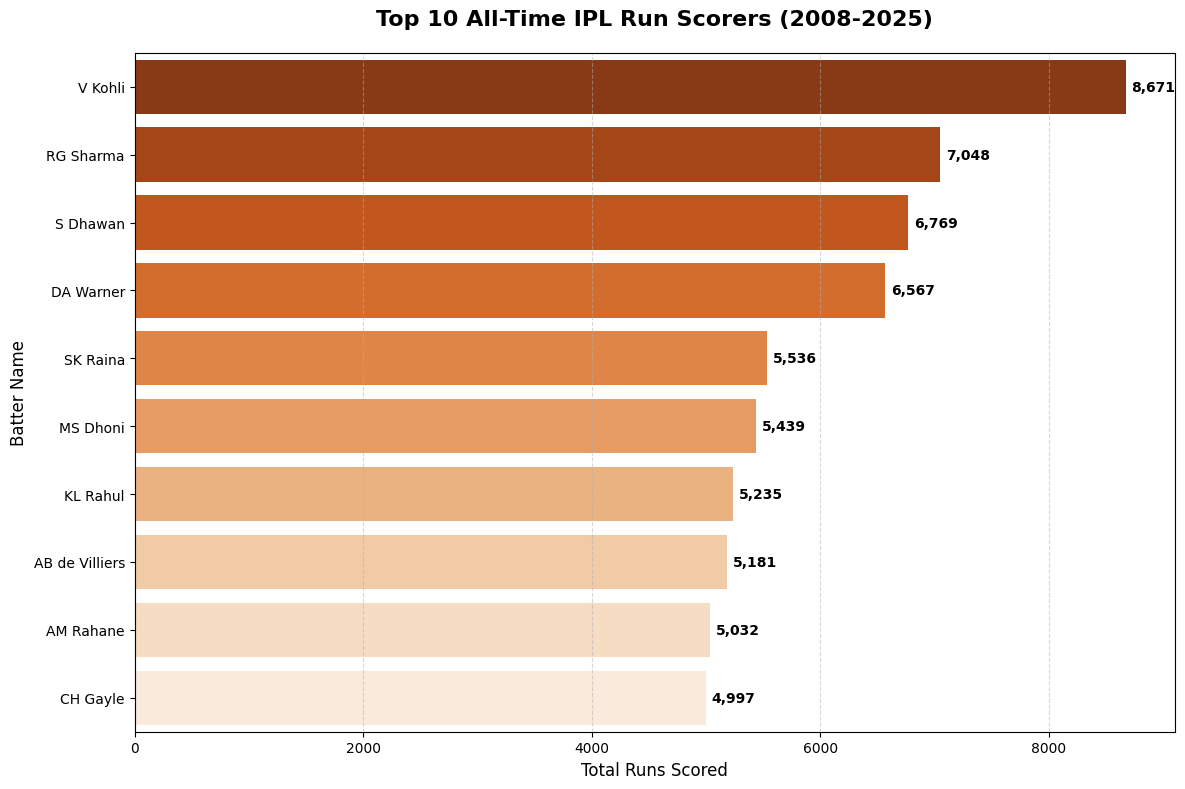

In [ ]:
#  Horizontal Bar Chart
plt.figure(figsize=(12, 8))

# Use 'Oranges_r' (with a capital O) for the professional gradient
ax = sns.barplot(data=top_batsmen, x='runs_batter', y='batter', palette='Oranges_r')

# 3. Add Professional Styling
plt.title('Top 10 All-Time IPL Run Scorers (2008-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Runs Scored', fontsize=12)
plt.ylabel('Batter Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Add Data Labels at the end of each bar
for i, v in enumerate(top_batsmen['runs_batter']):
    plt.text(v + 50, i, f'{int(v):,}', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Insight: Top players like Virat Kohli and Rohit Sharma dominate due to consistency across seasons, not just high-impact innings

## Question: Which players have played most balls(Most consistent batters) ?

In [ ]:
df_legal = df[~((df['runs_batter'] == 0) & (df['runs_extras'] > 0))]
df_legal.groupby('batter').size().sort_values(ascending=False).head(10).reset_index()

,batter,0
0,V Kohli,6453
1,RG Sharma,5277
2,S Dhawan,5226
3,DA Warner,4604
4,SK Raina,3977
5,AM Rahane,3958
6,MS Dhoni,3868
7,KL Rahul,3793
8,RV Uthappa,3717
9,KD Karthik,3509


### Insight:High ball count indicates trust and stability in batting order.

## Question: Which players scores runs with higher strike rates?

In [ ]:
df_legal = df[~((df['runs_batter'] == 0) & (df['runs_extras'] > 0))]
batting_stats = df_legal.groupby('batter').agg(
    runs=('runs_batter', 'sum'),
    balls_faced=('batter', 'count')
)

batting_stats['strike_rate'] = (batting_stats['runs'] / batting_stats['balls_faced']) * 100

batting_stats[batting_stats['balls_faced'] >= 1000].sort_values(by='strike_rate', ascending=False).head(10).reset_index()



,batter,runs,balls_faced,strike_rate
0,AD Russell,2655,1499,177.118079
1,SP Narine,1780,1024,173.828125
2,N Pooran,2293,1338,171.375187
3,Abhishek Sharma,1816,1097,165.542388
4,V Sehwag,2728,1697,160.754272
5,GJ Maxwell,2820,1761,160.136286
6,YBK Jaiswal,2166,1396,155.157593
7,AB de Villiers,5181,3355,154.426230
8,CH Gayle,4997,3267,152.953780
9,JC Buttler,4121,2708,152.178730


### Insight: Strike rate was calculated using only legal deliveries by excluding wide balls, ensuring an accurate representation of batting efficiency

### Some players may not have highest runs but have higher strike rates, making them more impactful in shorter formats

## Question:Who hits most boundaries?

In [ ]:
df.groupby('batter')['is_boundary'].sum().sort_values(ascending=False).head(10).reset_index()

,batter,is_boundary
0,V Kohli,1066
1,RG Sharma,943
2,S Dhawan,921
3,DA Warner,899
4,CH Gayle,767
5,SK Raina,710
6,AB de Villiers,667
7,RV Uthappa,663
8,KL Rahul,661
9,MS Dhoni,639


### Insight:Boundary-heavy players reduce dependency on strike rotation and accelerate scoring rate.

## Question: Which batter plays most dot balls?

In [ ]:
# Dot balls per batter
dot_balls = df_legal[df_legal['runs_batter'] == 0].groupby('batter').size()

# Total balls per batter
total_balls = df_legal.groupby('batter').size()

# Combine into one DataFrame
batting_dot_stats = pd.DataFrame({
    'dot_balls': dot_balls,
    'total_balls': total_balls
}).fillna(0)

# Calculate percentage
batting_dot_stats['dot_ball_%'] = (
    batting_dot_stats['dot_balls'] / batting_dot_stats['total_balls']
) * 100

batting_dot_stats = batting_dot_stats.sort_values(by='dot_ball_%', ascending=False)
batting_dot_stats[batting_dot_stats['total_balls']>1000].head(10)



,dot_balls,total_balls,dot_ball_%
batter,,,
SC Ganguly,567.0,1231,46.060114
NV Ojha,581.0,1293,44.934261
AC Gilchrist,628.0,1446,43.430152
DR Smith,738.0,1709,43.183148
SP Narine,437.0,1024,42.675781
CH Gayle,1387.0,3267,42.454852
M Vijay,893.0,2114,42.242195
BB McCullum,886.0,2130,41.596244
Yuvraj Singh,864.0,2094,41.260745


### Insight:A higher dot ball percentage indicates difficulty in rotating strike, which can build pressure and increase the likelihood of wickets in T20 cricket

# PLAYER RUNS DISTRIBUTUON

## Question: How batter scores runs(playing style)?


In [ ]:
batting_style = df_legal.groupby('batter').agg(
    singles=('is_single', 'sum'),
    boundaries=('is_boundary', 'sum'),
    balls=('batter', 'count'),
   total_runs=('runs_batter', 'sum')
)
batting_style['single_%'] = (batting_style['singles'] / batting_style['balls']) * 100
batting_style['boundary_%'] = (batting_style['boundaries'] / batting_style['balls']) * 100
batting_style = batting_style[batting_style['balls'] >= 500]



## Strike rotators (singles-heavy):

In [ ]:
batting_style.sort_values(by='single_%', ascending=False).head(10).reset_index()

,batter,singles,boundaries,balls,total_runs,single_%,boundary_%
0,JP Duminy,778,205,1598,2029,48.685857,12.828536
1,AK Markram,505,168,1057,1440,47.776727,15.894040
2,AD Mathews,265,73,568,724,46.654930,12.852113
3,SPD Smith,880,286,1916,2495,45.929019,14.926931
4,V Shankar,426,136,933,1233,45.659164,14.576635
5,Shakib Al Hasan,286,94,627,795,45.614035,14.992026
6,H Klaasen,394,187,864,1480,45.601852,21.643519
7,AR Patel,640,224,1409,1916,45.422285,15.897800
8,RA Jadeja,1111,357,2449,3260,45.365455,14.577379
9,B Sai Sudharsan,546,236,1211,1793,45.086705,19.488026


## Aggressive players (boundary-heavy):

In [ ]:

batting_style.sort_values(by='boundary_%', ascending=False).head(10)

,singles,boundaries,balls,total_runs,single_%,boundary_%
batter,,,,,,
PD Salt,173,178,582,1056,29.725086,30.584192
SP Narine,240,305,1024,1780,23.437500,29.785156
TM Head,228,181,657,1146,34.703196,27.549467
AD Russell,444,410,1499,2655,29.619746,27.351568
V Sehwag,555,440,1697,2728,32.704773,25.928108
YBK Jaiswal,446,351,1396,2166,31.948424,25.143266
Abhishek Sharma,369,275,1097,1816,33.637192,25.068368
N Pooran,495,325,1338,2293,36.995516,24.289985
P Simran Singh,274,212,874,1355,31.350114,24.256293


## aggression_index= boundary% - single%

In [ ]:

batting_style['aggression_index'] = batting_style['boundary_%'] - batting_style['single_%']
batting_style.sort_values(by='aggression_index', ascending=False).head(10)

,singles,boundaries,balls,total_runs,single_%,boundary_%,aggression_index
batter,,,,,,,
SP Narine,240,305,1024,1780,23.437500,29.785156,6.347656
PD Salt,173,178,582,1056,29.725086,30.584192,0.859107
ST Jayasuriya,126,123,517,768,24.371373,23.791103,-0.580271
AD Russell,444,410,1499,2655,29.619746,27.351568,-2.268179
AC Gilchrist,414,331,1446,2069,28.630705,22.890733,-5.739972
V Sehwag,555,440,1697,2728,32.704773,25.928108,-6.776665
YBK Jaiswal,446,351,1396,2166,31.948424,25.143266,-6.805158
P Simran Singh,274,212,874,1355,31.350114,24.256293,-7.093822
TM Head,228,181,657,1146,34.703196,27.549467,-7.153729


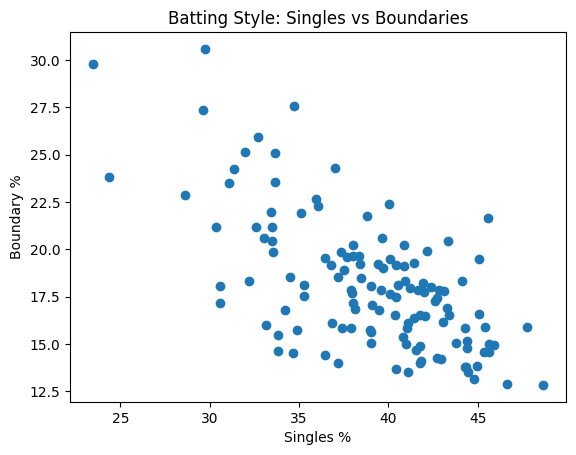

In [ ]:

plt.scatter(batting_style['single_%'], batting_style['boundary_%'])
plt.xlabel('Singles %')
plt.ylabel('Boundary %')
plt.title('Batting Style: Singles vs Boundaries')

plt.show()

### Insight: Batters exhibit distinct playing styles, with some relying heavily on boundary hitting for quick scoring, while others focus on strike rotation through singles. The most effective players balance both approaches, maintaining scoring momentum while minimizing dot balls.

# Runs vs Strike Rate (Effectiveness)

## Question: To identify most effective_players?

In [ ]:
batting_stats = batting_stats[batting_stats['balls_faced'] >= 500]

avg_runs = batting_stats['runs'].mean()
avg_sr = batting_stats['strike_rate'].mean()

effective_players = batting_stats[
    (batting_stats['runs'] > avg_runs) &
    (batting_stats['strike_rate'] > avg_sr)
]
effective_players.head()

,runs,balls_faced,strike_rate
batter,,,
AB de Villiers,5181,3355,154.426230
AD Russell,2655,1499,177.118079
CH Gayle,4997,3267,152.953780
DA Miller,3077,2162,142.321924
DA Warner,6567,4604,142.636838


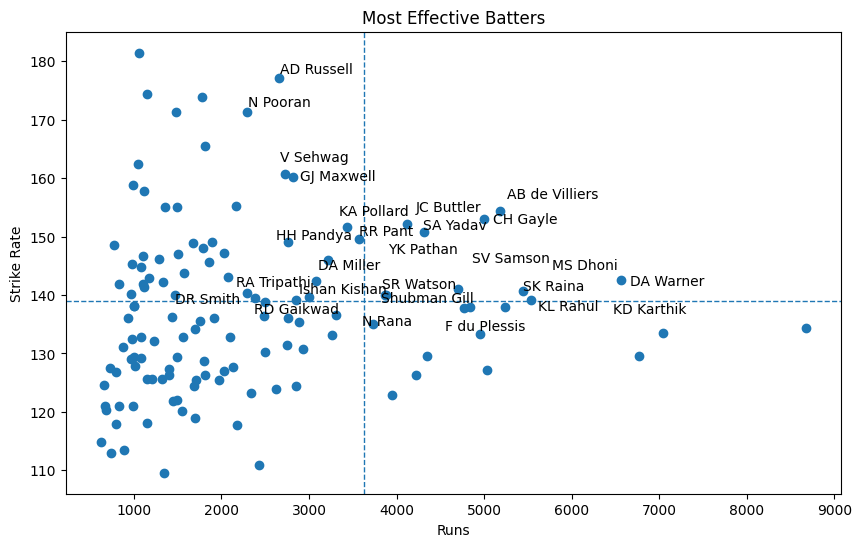

In [ ]:
# !pip install adjustText
from adjustText import adjust_text
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(batting_stats['runs'], batting_stats['strike_rate'])

texts = []

for batter, row in effective_players.iterrows():
    texts.append(
        plt.text(row['runs'], row['strike_rate'], batter, fontsize=10)
    )

adjust_text(texts)

plt.xlabel('Runs')
plt.ylabel('Strike Rate')
plt.title('Most Effective Batters')
filtered = batting_stats[batting_stats['runs'] >= 2000]

avg_runs = filtered['runs'].mean()
avg_sr = filtered['strike_rate'].mean()


plt.axvline(avg_runs, linestyle='--',linewidth=1)
plt.axhline(avg_sr, linestyle='--',linewidth=1)
plt.show()

In [ ]:
top_players = batting_stats[batting_stats['runs'] >= 3000]
top_players = top_players[
    (top_players['strike_rate'] > avg_sr)
]

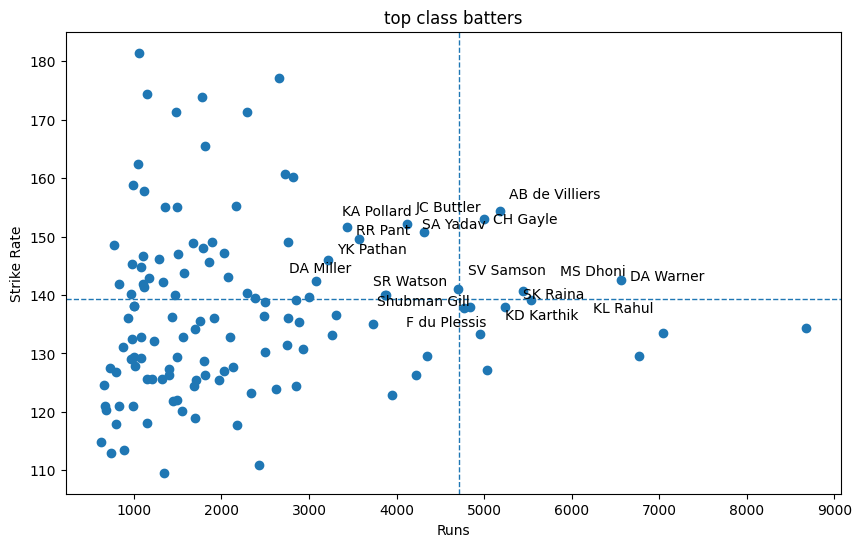

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(batting_stats['runs'], batting_stats['strike_rate'])

texts = []

for batter, row in top_players.iterrows():
    texts.append(
        plt.text(row['runs'], row['strike_rate'], batter, fontsize=10)
    )

adjust_text(texts)

plt.xlabel('Runs')
plt.ylabel('Strike Rate')
filtered = batting_stats[batting_stats['runs'] >= 3000]

avg_runs = filtered['runs'].mean()
avg_sr = filtered['strike_rate'].mean()

plt.axvline(avg_runs, linestyle='--',linewidth=1)
plt.axhline(avg_sr, linestyle='--',linewidth=1)
plt.title('top class batters')
plt.show()

### Insight: Players were first filtered based on minimum balls faced to remove small sample bias. Effectiveness was then determined using above-average run volume and strike rate, ensuring a balanced evaluation of consistency and scoring efficiency

### The quadrant-based analysis reveals a clear separation of batting roles in T20 cricket — high-volume scorers tend to have moderate strike rates (anchors), while high strike-rate players often have lower run aggregates (finishers). Only a few players break this trade-off by maintaining both high run totals and high strike rates, making them statistically elite and match-defining performers

### The clustering of most players below the average strike rate line suggests that maintaining a high scoring rate over a long career is significantly more challenging than achieving short bursts of high strike rates.

# Effectiveness Score


In [ ]:
# Keep numeric column
batting_stats['effectiveness_score'] = (
    batting_stats['runs'] * batting_stats['strike_rate']
)

# Create display column
batting_stats['effectiveness_score_display'] = batting_stats['effectiveness_score'].astype(int).map('{:,}'.format)
batting_stats=batting_stats.sort_values(by='effectiveness_score', ascending=False)
batting_stats.head(10)

,runs,balls_faced,strike_rate,effectiveness_score,effectiveness_score_display
batter,,,,,
V Kohli,8671,6453,134.371610,1.165136e+06,"1,165,136"
RG Sharma,7048,5277,133.560735,9.413361e+05,"941,336"
DA Warner,6567,4604,142.636838,9.366961e+05,"936,696"
S Dhawan,6769,5226,129.525450,8.767578e+05,"876,757"
AB de Villiers,5181,3355,154.426230,8.000823e+05,"800,082"
SK Raina,5536,3977,139.200402,7.706134e+05,"770,613"
MS Dhoni,5439,3868,140.615305,7.648066e+05,"764,806"
CH Gayle,4997,3267,152.953780,7.643100e+05,"764,310"
KL Rahul,5235,3793,138.017400,7.225211e+05,"722,521"


### Insight: The effectiveness score highlights players who combine both high run accumulation and high scoring efficiency. Unlike traditional metrics that evaluate either consistency or strike rate independently, this combined metric identifies batters who deliver sustained impact over time while maintaining an aggressive scoring rate

### Players with extremely high strike rates but low run aggregates rank lower on the effectiveness score, indicating that short bursts of aggressive performance are less impactful than sustained high-quality contributions

# **Batting profile table**

In [ ]:
final_batting = batting_stats.merge(
    batting_style,
    left_index=True,
    right_index=True
)
final_batting = final_batting.merge(
    batting_dot_stats[['dot_ball_%']],
    left_index=True,
    right_index=True
)
final_batting = final_batting[[
    'runs',
    'strike_rate',
    'dot_ball_%',
    'boundary_%',
    'single_%',
    'effectiveness_score',
    'effectiveness_score_display'
]]
final_batting = final_batting.sort_values(by='effectiveness_score', ascending=False).reset_index()
final_batting=final_batting.rename(columns={'index':'batter'})
final_batting.head()

,batter,runs,strike_rate,dot_ball_%,boundary_%,single_%,effectiveness_score,effectiveness_score_display
0,V Kohli,8671,134.371610,32.264063,16.519448,43.406168,1.165136e+06,"1,165,136"
1,RG Sharma,7048,133.560735,37.066515,17.870002,39.605837,9.413361e+05,"941,336"
2,DA Warner,6567,142.636838,35.360556,19.526499,36.446568,9.366961e+05,"936,696"
3,S Dhawan,6769,129.525450,35.954841,17.623421,40.088021,8.767578e+05,"876,757"
4,AB de Villiers,5181,154.426230,29.299553,19.880775,42.175857,8.000823e+05,"800,082"


### Insight: The combined analysis reveals that players with lower dot ball percentages and balanced boundary and single contributions tend to achieve higher effectiveness scores, indicating the importance of maintaining scoring momentum in T20 cricket.

In [ ]:
path = '/content/drive/My Drive/IPL_PROJECT/'
batting_stats.to_csv(path + 'batting_stats.csv', index=True)

# TOP 10 BATTERS IN IPL

In [ ]:
final_batting.head(10)

,batter,runs,strike_rate,dot_ball_%,boundary_%,single_%,effectiveness_score,effectiveness_score_display
0,V Kohli,8671,134.371610,32.264063,16.519448,43.406168,1.165136e+06,"1,165,136"
1,RG Sharma,7048,133.560735,37.066515,17.870002,39.605837,9.413361e+05,"941,336"
2,DA Warner,6567,142.636838,35.360556,19.526499,36.446568,9.366961e+05,"936,696"
3,S Dhawan,6769,129.525450,35.954841,17.623421,40.088021,8.767578e+05,"876,757"
4,AB de Villiers,5181,154.426230,29.299553,19.880775,42.175857,8.000823e+05,"800,082"
5,SK Raina,5536,139.200402,32.084486,17.852653,42.821222,7.706134e+05,"770,613"
6,MS Dhoni,5439,140.615305,32.264736,16.520165,41.778697,7.648066e+05,"764,806"
7,CH Gayle,4997,152.953780,42.454852,23.477196,31.068258,7.643100e+05,"764,310"
8,KL Rahul,5235,138.017400,32.559979,17.426839,42.736620,7.225211e+05,"722,521"
9,KD Karthik,4843,138.016529,32.801368,17.868339,41.635794,6.684140e+05,"668,414"


# **Key Batting Insights**

### **Elite Batters Insight:**  Only a small group of players like AB de Villiers, Chris Gayle, and Jos Buttler fall in the high-runs and high-strike-rate category, indicating that combining consistency with aggressive scoring is rare and defines elite T20 batters.

### **Role-Based Classification:**  Batters naturally fall into distinct roles — Players such as Virat kohli and KL rahul act as anchors with high run accumulation but relatively moderate strike rates, while players like Andre Russell and Nicholas Pooran serve as finishers with high strike rates but lower total runs. This highlights the strategic diversity in T20 batting


### **Impact of Dot Balls**: A high dot ball percentage significantly reduces a batter’s scoring efficiency, as it builds pressure and limits scoring opportunities, often leading to lower strike rates

### **Playing Style Matters** :Players with a balanced approach of rotating strike (singles) and hitting boundaries tend to perform more consistently compared to those relying solely on aggressive stroke play

### **Effectiveness Score**: The effectiveness score reveals that the most impactful batters are those who maintain both high run totals and high strike rates, rather than excelling in only one dimension

### **High value players**: Players with extremely high strike rates but low run aggregates contribute in short bursts, whereas players with sustained performance across both metrics have a greater long-term impact on match outcomes

### **Final Conclusion**: Overall, T20 batting success is driven by a balance between consistency, strike rotation, and boundary hitting, with elite players excelling across all these dimensions rather than specializing in just one